# SuperStore Data Visualization


## Данные

Источник данных: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final. 

Датасет содержит информацию о продажах и прибыли супермаркета. 


Анализ и изучение данных о реализации товаров и услуг помогает принять обоснованные решения о развитии бизнеса: нужно ли расширить ассортимент, какие рекламные каналы выбрать и какой план продаж составить. Также поможет понять, почему продажи не растут, и какие факторы на это влияют. Анализ объема продаж подсвечивает, какие товары или услуги приносят больший доход, а какие не пользуются спросом. 

##### Описание проекта:
На основе данных о продажах супермаркета мы проведем комплексный анализ, который выявит:

- Наиболее и наименее прибыльные категории товаров

- Эффективность различных способов доставки

- Сегменты клиентов с разной рентабельностью

- Региональные особенности продаж

##### Проблематика:

Первичный анализ выявил несколько ключевых проблем:

- Наличие убыточных товарных позиций, несмотря на значительные объемы продаж

- Неравномерное распределение прибыли по регионам и категориям

- Обратная корреляция между объемами продаж и рентабельностью в некоторых сегментах

##### Цель исследования:

Разработать практические рекомендации по:

- Оптимизации ассортимента

- Корректировке ценовой политики

- Повышению эффективности логистики

- Улучшению маркетинговых стратегий


Конкретные управленческие решения, которые позволят увеличить общую рентабельность на 15-20%, сократить количество убыточных позиций и улучшить распределение ресурсов между направлениями бизнеса

#### Описание данных

<table align="left">
    <tbody>
        <tr>
            <td>Название</td>
            <td>Описание</td>
        </tr>
        <tr>
            <td>Row ID</td>
            <td>Unique ID for each row</td>
        </tr>
        <tr>
            <td>Order ID</td>
            <td>Unique Order ID for each Customer</td>
        </tr>
        <tr>
            <td>Order Date</td>
            <td>Order Date of the product</td>
        </tr>
        <tr>
            <td>Ship Date</td>
            <td>Shipping Date of the Product</td>
        </tr>
        <tr>
            <td>Ship Mode</td>
            <td>Shipping Mode specified by the Customert</td>
        </tr>
        <tr>
            <td>Customer ID</td>
            <td>Unique ID to identify each Custome</td>
        </tr>
        <tr>
            <td>Customer Name</td>
            <td>Name of the Customer</td>
        </tr>
        <tr>
            <td>Segment</td>
            <td>The segment where the Customer belongs</td>
        </tr>
        <tr>
            <td>Country</td>
            <td>Country of residence of the Customer</td>
        </tr>
        <tr>
            <td>City</td>
            <td>City of residence of of the Customer</td>
        </tr>
        <tr>
            <td>State</td>
            <td>State of residence of the Customer</td>
        </tr>
        <tr>
            <td>Postal Code</td>
            <td>Postal Code of every Customer</td>
        </tr>
        <tr>
            <td>Region</td>
            <td>Region where the Customer belong</td>
        </tr>
        <tr>
            <td>Product ID</td>
            <td>Unique ID of the Produc</td>
        </tr>
        <tr>
            <td>Category</td>
            <td>Category of the product ordered</td>
        </tr>
        <tr>
            <td>Sub-Category</td>
            <td>Sub-Category of the product ordered</td>
        </tr>
        <tr>
            <td>Product Name</td>
            <td>Name of the Product</td>
        </tr>
        <tr>
            <td>Sales</td>
            <td>Sales of the Product</td>
        </tr>
        <tr>
            <td>Quantity</td>
            <td>Quantity of the Product</td>
        </tr>
        <tr>
            <td>Discount</td>
            <td>Discount provided</td>
        </tr>
        <tr>
            <td>Profit</td>
            <td>Profit/Loss incurred</td>
        </tr>
    </tbody>
</table>

В анализе мы имеем данные о продажах супермаркета США в период с 2014 по 2017гг. по различным категориям, подкатегориям, сегментам покупателей, регионам.

In [ ]:
# импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly
import squarify 
import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns=None

### Импорт данных и предварительная обработка

Загрузим данные:

In [ ]:
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

Выведем первые строки для оценки правильности загрузки данных:

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Получим информацию о датафрейме:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

- 📊 Таблица содержит 9 994 строки и 21 колонку.

- Пропущенных значений нет — все столбцы полностью заполнены.

Типы данных:

- Числовые столбцы (int64, float64): Row ID, Postal Code, Sales, Quantity, Discount, Profit.

- Объектные столбцы (object) — 15 штук, включая даты (Order Date, Ship Date), идентификаторы, текстовые названия и категории.

Приступим к анализу описательных статистик датасета:

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


📈 1. Sales (Продажи):
- Среднее значение: ~229.86
- Медиана (50%): ~54.49
- Максимум: >22 000
- Стандартное отклонение: довольно высокое (~623), что указывает на сильную разбросанность значений.

Распределение продаж сильно асимметричное, с большим количеством маленьких продаж и немногими очень крупными — возможны выбросы.

📉 2. Profit (Прибыль):
- Средняя прибыль: ~28.66
- Медиана: всего ~8.67
- Минимум: -6 600 (!), максимум: +8 400

Есть убыточные заказы с большими отрицательными значениями. Также наблюдается сильная вариативность, возможны ошибки или специфические ситуации (например, высокая скидка или возвраты).

📦 3. Quantity (Количество товара):
- Значения в диапазоне от 1 до 14, среднее — около 3.8

Большинство заказов включает малое количество товаров, что типично для розничной торговли.

🎁 4. Discount (Скидка):
- Среднее значение: ~15.6%
- 75% значений — не превышают 20%, но есть скидки до 80%.

Скидки в большинстве случаев умеренные, однако есть экстремальные случаи — важно нам будет проанализировать, как скидка влияет на прибыль.

📮 5. Postal Code и Row ID:
- В числовой форме, но не несут смысловой нагрузки для анализа (служебные идентификаторы).

Их можно исключить из числового анализа

Столбцы Order Date и Ship Date необходимо преобразовать в формат datetime, это нам позволит работать с временными метками в данных, приступим:

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

Просмотрим диапазон даты заказа:

In [ ]:
df['Order Date'].agg(['min', 'max'])

min   2014-01-03
max   2017-12-30
Name: Order Date, dtype: datetime64[ns]

Для анализа сезонности, трендов продаж и прибыли нам важно понимать, в каком году, месяце и дне происходили заказы. Это даст возможность делать группировки по времени и выявлять интересные зависимости.

In [ ]:
df['Order_year'] = df['Order Date'].dt.year
df['Order_month'] = df['Order Date'].dt.month
df['Order_day'] = df['Order Date'].dt.day

Чтобы понять, насколько прибыльной была каждая конкретная продажа, введём метрику рентабельности.

Она рассчитывается как отношение прибыли к объёму продаж. Это поможет:
- выявить убыточные заказы (рентабельность < 0);
- найти максимально эффективные продажи (высокая рентабельность);
- провести анализ скидок и их влияния на итоговую прибыль.

In [ ]:
df['Profitability'] = df['Profit']/df['Sales']

🧾 Проверим, что все столбцы создались корректно и без пропусков:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

🧾 Просмотр статистики для категориальных (object) столбцов:

In [ ]:
df.select_dtypes(include=['object']).describe()

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,531,49,4,1862,3,17,1850
top,CA-2017-100111,Standard Class,WB-21850,William Brown,Consumer,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,915,2001,3203,19,6026,1523,48


✂️ Столбец 'Country' содержит только одно уникальное значение — 'United States' во всех строках. Такой признак не несёт аналитической ценности и только увеличивает размерность данных, поэтому его можно безопасно удалить.

In [ ]:
df = df.drop('Country', axis=1)

📌 В рамках первичной подготовки данных были выполнены следующие шаги:

- Столбцы Order Date и Ship Date были приведены к типу datetime, что открыло возможность для временного анализа.

- Из даты заказа были извлечены год (Order_year), месяц (Order_month) и день (Order_day). 

- Рассчитана рентабельность (Profitability). Это отношение позволит судить об эффективности каждой сделки, выявить убыточные продажи и общие закономерности.

- Удалили столбец Country, так как он содержал только одно значение (США)

Таким образом, данные стали более структурированными и подготовленными для дальнейшего анализа и визуализаций.

----------

### Предварительный анализ данных

Сделаем анализ структуры данных:

In [ ]:
rows, columns = df.shape[0], df.shape[1]
print(f'количество строк: {rows}; количество столбцов: {columns}')

количество строк: 9994; количество столбцов: 24


Проверим на пропущенные значения:

In [ ]:
values_none = df.isnull().sum().sum()
print(f'количество пропусков: {values_none}')

количество пропусков: 0


Также необходимо проверить набор данных на дубликаты:

In [ ]:
values_duples = df.duplicated().sum()
print(f'количество дубликатов: {values_duples}')

количество дубликатов: 0


📊 На данном этапе мы провели первичный анализ качества данных и установили, что:

- Данные полные — пропуски отсутствуют.
- Данные уникальны — дубликаты не обнаружены.
- Размерность подходит для сложного моделирования (9994 × 24).

### В каком штате больше всего продаж?

Определим количество продаж по штатам

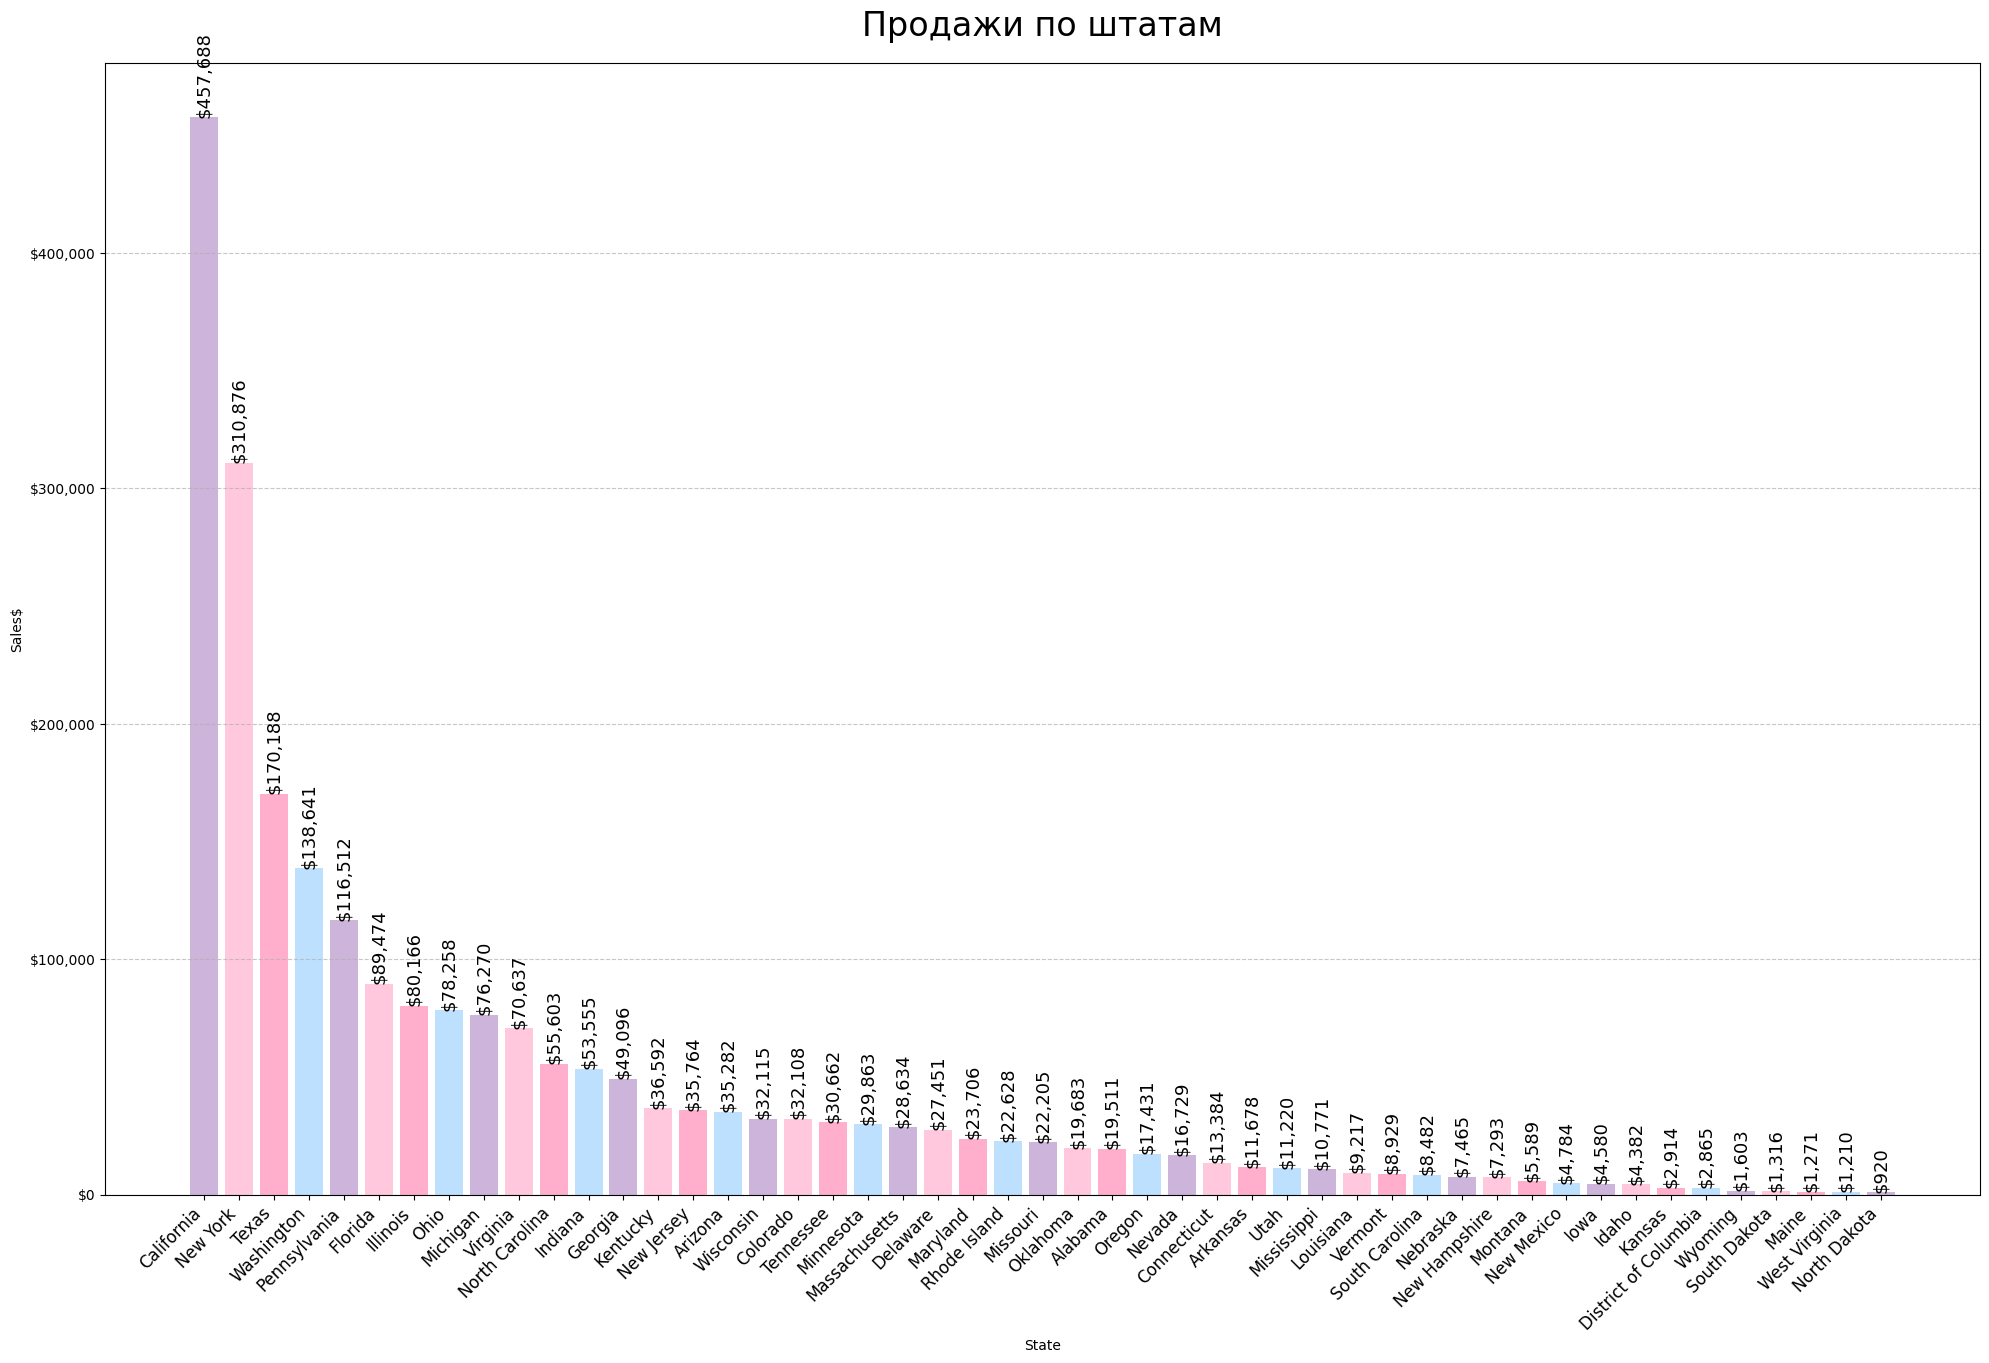

In [ ]:
df_bar = df[['State', 'Sales']]
df_bar = df_bar.groupby('State').sum().sort_values(by = 'Sales', ascending=False)
colors = ['#CDB4DB', '#FFC8DD', '#FFAFCC', '#BDE0FE']
plt.figure(figsize=(20,15))
bars = plt.bar(x=df_bar.index, height='Sales', color=colors, width=0.8, data =df_bar)
plt.title('Продажи по штатам', size=24, pad=20)
plt.xlabel('State')
plt.ylabel('Sales$')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', ha='center', va='bottom', rotation=90, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.subplots_adjust(bottom=0.2)
plt.show()

##### 📌 Ключевые наблюдения:

- Калифорния значительно лидирует по объёму продаж.

- На топ-5 штатов (Калифорния, Нью-Йорк, Техас, Вашингтон и Пенсильвания) приходится основная доля общих продаж.

- После ведущих штатов наблюдается заметный спад продаж, при этом остальные штаты демонстрируют относительно схожие, но более низкие показатели.

### Определим прибыль по штатам

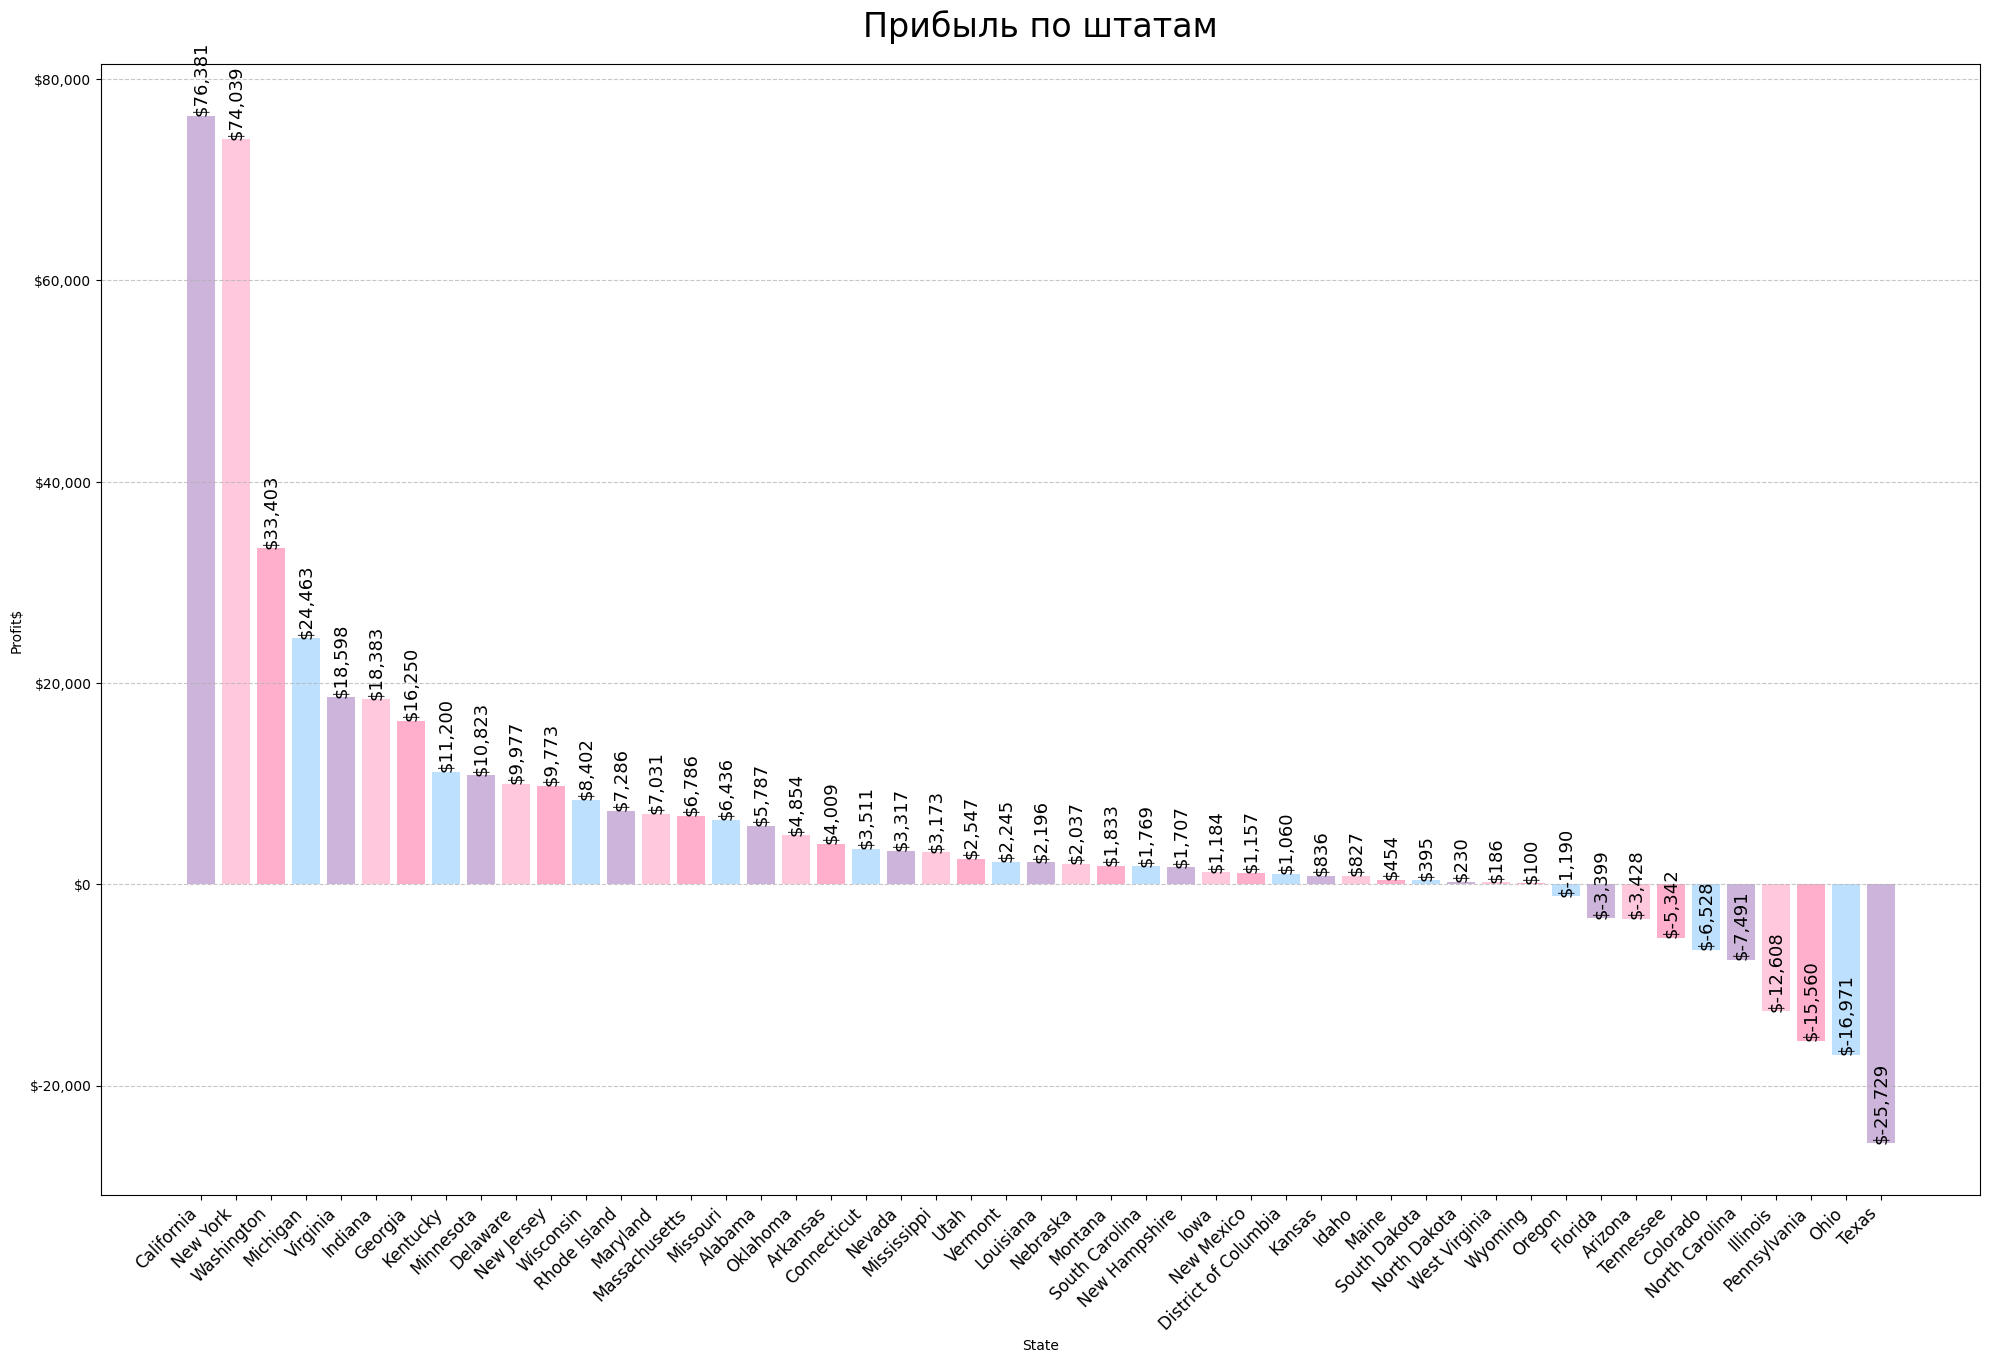

In [ ]:
df_bar = df[['State', 'Profit']]
df_bar = df_bar.groupby('State').sum().sort_values(by = 'Profit', ascending=False)
plt.figure(figsize=(20,15))
bars = plt.bar(x=df_bar.index,  height='Profit', color=colors, width=0.8, data =df_bar)
plt.title('Прибыль по штатам', size=24, pad=20)
plt.xlabel('State')
plt.ylabel('Profit$')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', ha='center', va='bottom', rotation=90, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.subplots_adjust(bottom=0.2)
plt.show()

 ##### 📌Ключевые наблюдения:
- Калифорния лидирует по прибыли, повторяя свои высокие показатели продаж.
- Нью-Йорк и Вашингтон следуют сразу за ней, также соответствуя своим высоким позициям в рейтинге продаж.
- Интересно, что некоторые штаты демонстрируют отрицательную прибыль, что указывает на убытки несмотря на объемы продаж.
- Техас, занимающий 3-е место по продажам, не входит в топ-5 по прибыли. Это может свидетельствовать о:
  - Более низкой рентабельности или высоких операционных расходах в Техасе.

- Некоторые штаты с умеренными продажами показывают более высокую прибыль (например, Иллинойс), что говорит о лучшей маржинальности или эффективном управлении затратами.

##### Штаты с отрицательной прибылью:
Такие штаты как Огайо и Пенсильвания показывают убытки при хороших показателях продаж.

Это ставит вопросы о ценовой политике, операционных расходах или возможной стратегии loss-leader в этих регионах.

Прибыль не всегда коррелирует с продажами:
Распределение прибыли по штатам более неравномерно по сравнению с продажами, что подчеркивает: высокие продажи не всегда означают высокую прибыльность.

---

##### Бизнес-инсайты:

- Ключевые рынки: Штаты типа Калифорнии, Нью-Йорка и Вашингтона являются приоритетными, демонстрируя хорошие результаты как по продажам, так и по прибыли. Их опыт можно использовать как эталон для других регионов.

- Зоны для улучшения: Штаты с высокими продажами, но низкой или отрицательной прибылью (например, Техас, Огайо) требуют пересмотра операционных затрат, ценовой стратегии или продуктового микса.

- Эффективные операции: Штаты с умеренными продажами, но высокой прибылью (например, Иллинойс) могут дать ценные инсайты об эффективном управлении затратами и рентабельных продуктах.

- Оценка рисков: Штаты с отрицательной прибылью представляют финансовый риск и могут потребовать срочных мер для улучшения показателей.

In [ ]:
df_pie = df[['Category', 'Sales', 'Profit']]
df_pie = df_pie.groupby('Category').sum().reset_index()

# подсчет прибыли по категориям в процентах
total_profit = df_pie['Profit'].sum()
df_pie['percentage'] = df_pie['Profit']/total_profit*100
df_pie = df_pie.sort_values('Profit', ascending=False).reset_index(drop=True)
df_pie

,Category,Sales,Profit,percentage
0,Technology,836154.0330,145454.9481,50.787870
1,Office Supplies,719047.0320,122490.8008,42.769579
2,Furniture,741999.7953,18451.2728,6.442551


### Прибыль по подкатегориям

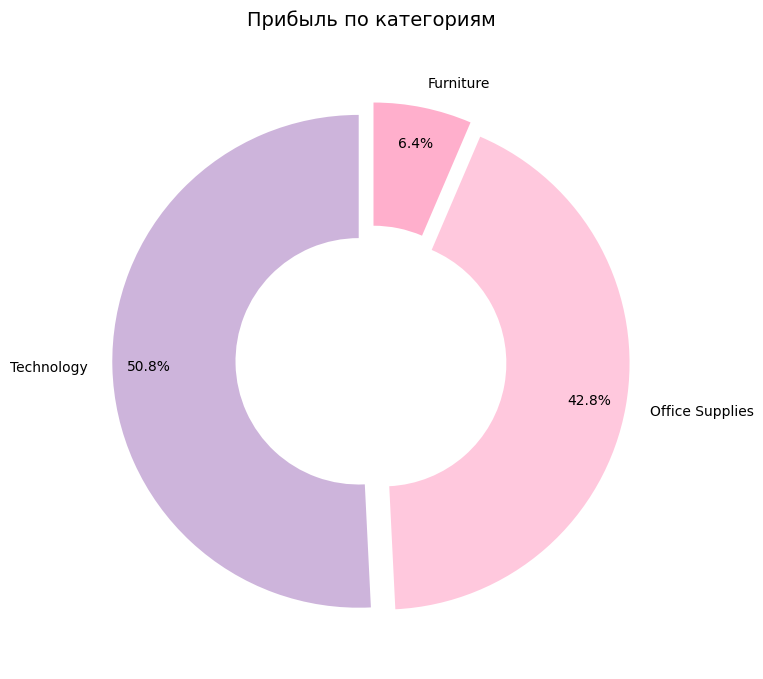

In [ ]:
plt.figure(figsize=(10,8))
plt.title('Прибыль по категориям', size=14, pad=20)
plt.pie(df_pie['Profit'], labels=df_pie['Category'], colors= colors, autopct='%1.1f%%', pctdistance=0.85, explode=[0.05] * len(df_pie), startangle=90, wedgeprops=dict(width=0.5))
plt.show()

##### Анализ прибыли:

- Значительный вклад технологического сегмента в прибыль указывает на его высокую рентабельность или стратегическую важность для компании.

- Несмотря на минимальный объем продаж, офисные принадлежности обеспечивают более пятой части прибыли, подтверждая их значение для бизнеса.

- Распределение прибыли не всегда соответствует объемам продаж, что подчеркивает важность учета как выручки, так и рентабельности при принятии решений.

- Зависимость компании от технологического сегмента (почти половина прибыли) создает:

  - Возможности для роста

  - Потенциальные риски при изменении рыночной ситуации

### Продажи по категориям

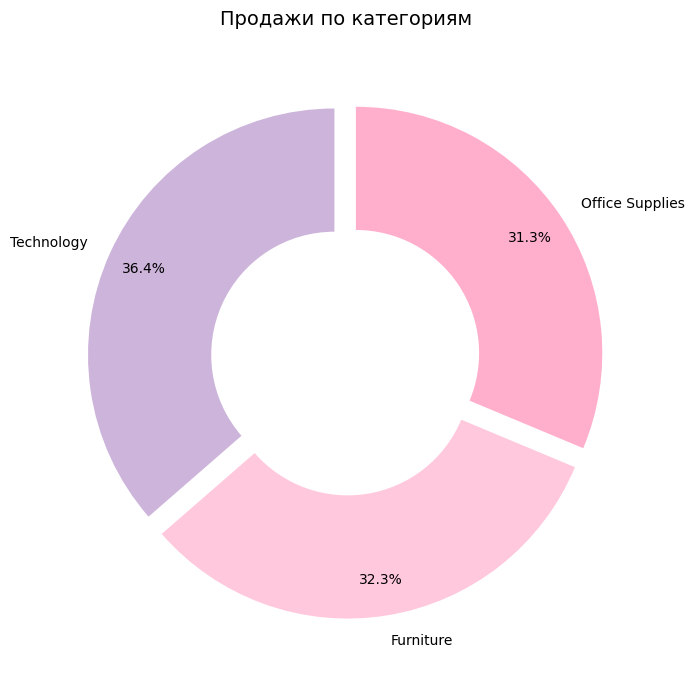

In [ ]:
df_pie = df_pie.sort_values('Sales', ascending=False).reset_index(drop=True)
plt.figure(figsize=(10,8))
plt.title('Продажи по категориям', size=14, pad=20)
plt.pie(df_pie['Sales'], labels=df_pie['Category'], colors= colors, autopct='%1.1f%%', pctdistance=0.85, explode=[0.05] * len(df_pie), startangle=90, wedgeprops=dict(width=0.5))
plt.show()

##### Вывод: 

Продажи по трем категориям распределены практически равномерно, несмотря на различия, выявленные при анализе прибыли

Учитывая значительный вклад технологий в прибыль, компания может рассмотреть возможность расширения этой категории в странах с низкими показателями.

### Продажи по сегментам

In [ ]:
df_segments = df[['Segment', 'Sales']]
df_segments = df_segments.groupby('Segment').sum().reset_index().sort_values(by='Sales', ascending=False)
df_segments

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


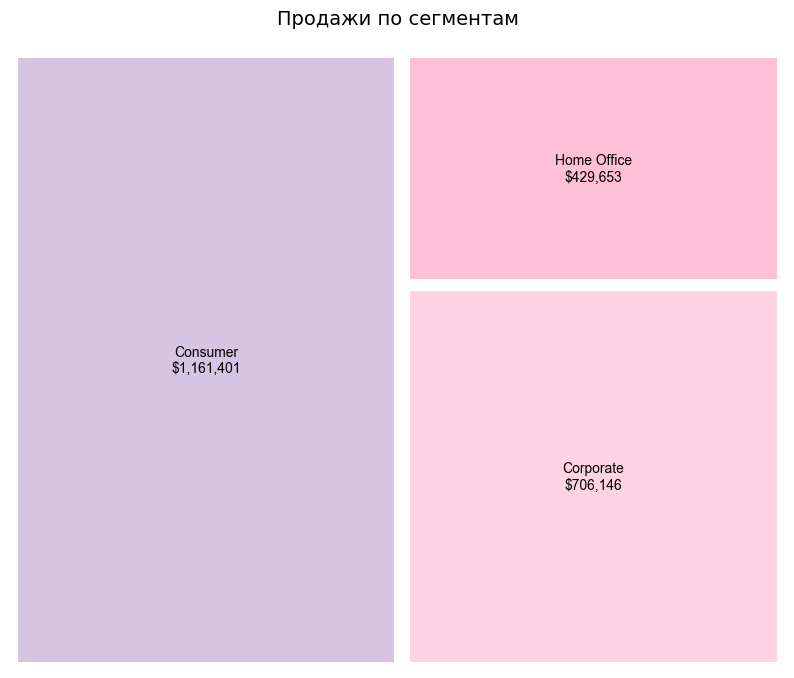

In [ ]:
df_segments['Sales_format'] = df_segments['Sales'].apply(lambda x:f'${x:,.0f}')
labels = df_segments.apply(lambda x:f"{x['Segment']}\n{x['Sales_format']}", axis=1)

plt.figure(figsize=(10,8))
squarify.plot(sizes=df_segments['Sales'], label=labels, color=colors, alpha=0.8, pad=0.2, text_kwargs={'fontname':'Arial'})
plt.title('Продажи по сегментам', size=14, pad=20)
plt.axis('off')
plt.show()

##### Вывод: 

Pз данного графика можно увидеть, что самой прибыльной категорией по продажам является категория "Consumer", поэтому можно сделать следующие рекомендации:

- Предложить таргетированный маркетинг: Учитывая доминирование потребительского сегмента в продажах, компании следует сосредоточиться на потребительских маркетинговых стратегиях, особенно в высокоэффективных штатах.

- Сделать фокус на домашние офисы: Хотя сегмент домашних офисов самый маленький, он может представлять возможность для роста. Компании стоит изучить способы увеличения продаж для этого сегмента, возможно через специализированные продукты или маркетинговые кампании.

### Прибыль в разных сегментах

In [ ]:
df_segments_profit = df[['Segment', 'Profit']]
df_segments_profit = df_segments_profit.groupby('Segment').sum().reset_index().sort_values(by='Profit', ascending=False)
df_segments_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


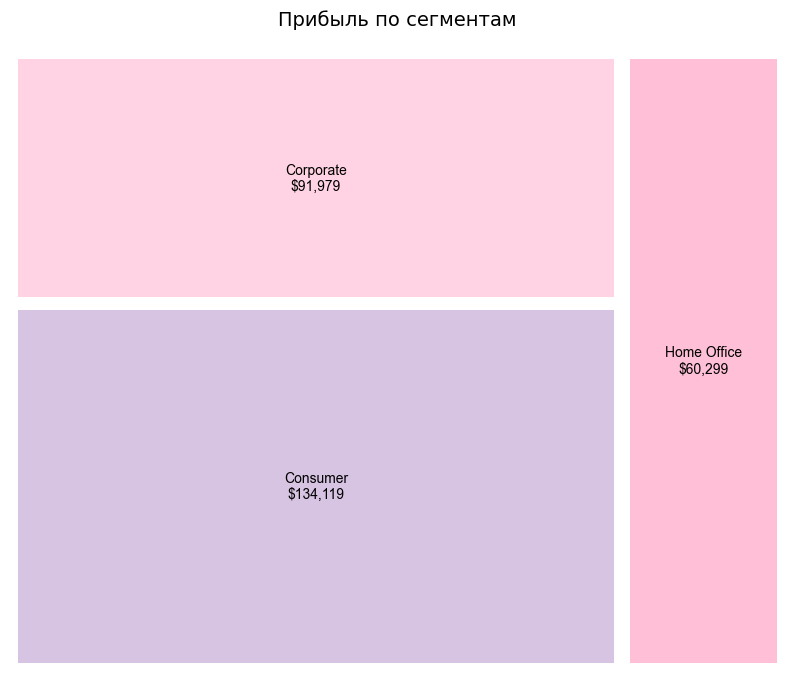

In [ ]:
df_segments_profit['Profit_format'] = df_segments_profit['Profit'].apply(lambda x:f'${x:,.0f}')
labels = df_segments_profit.apply(lambda x:f"{x['Segment']}\n{x['Profit_format']}", axis=1)

plt.figure(figsize=(10,8))
squarify.plot(sizes=df_segments_profit['Profit'], label=labels, color=colors, alpha=0.8, pad=0.2, text_kwargs={'fontname':'Arial'})
plt.title('Прибыль по сегментам', size=14, pad=20)
plt.axis('off')
plt.show()

##### Анализ сегментов:

- Разница в размерах между сегментами подчеркивает различную важность каждой группы клиентов для прибыли компании.

- Распределение прибыли может не коррелировать напрямую с объемом продаж, что подчеркивает необходимость учитывать как выручку, так и рентабельность при анализе сегментов.

- Понимание рентабельности сегментов критически важно для разработки целевых маркетинговых стратегий, распределения ресурсов и выявления возможностей роста.

- Компании следует изучить факторы, влияющие на рентабельность каждого сегмента, такие как модели покупок, предпочтения продуктов и стоимость обслуживания.

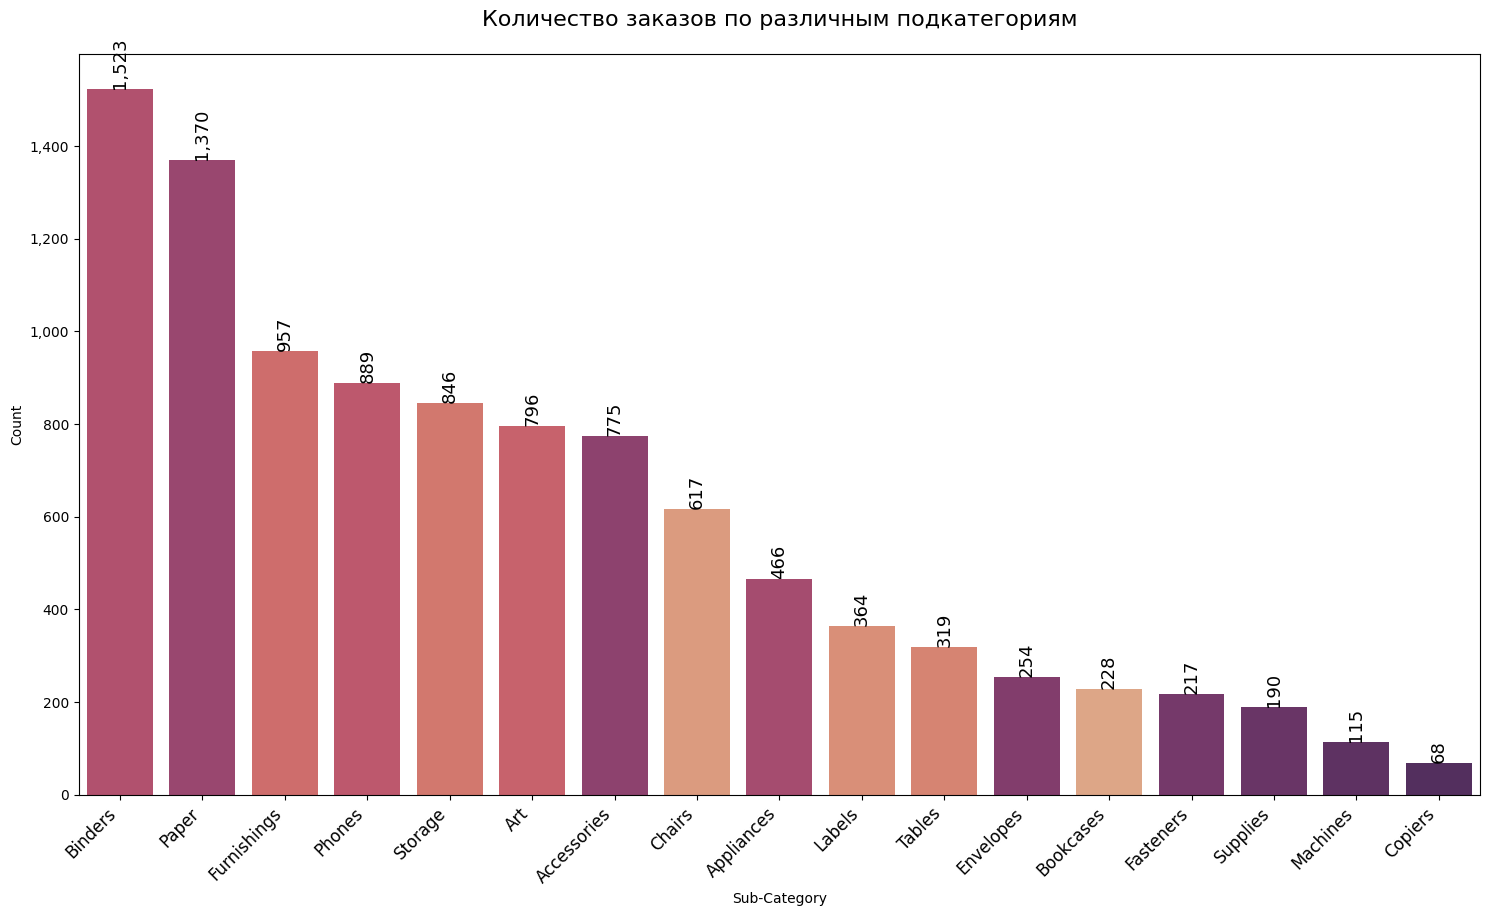

In [67]:
df_sub_category = df['Sub-Category'].value_counts()
df_sort_sub_category = df[df['Sub-Category'].isin(df_sub_category.index)]
plt.figure(figsize=(15,10))
ax = sns.countplot(x='Sub-Category', data=df_sort_sub_category, order=df_sub_category.index, palette='flare', hue='Sub-Category')
plt.title('Количество заказов по различным подкатегориям', size=16, pad=20)
plt.xlabel('Sub-Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
for i, v in enumerate(df_sub_category):    
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', rotation=90, fontsize=13)
plt.tight_layout()

# Adjust bottom margin
plt.subplots_adjust(bottom=0.2)
plt.show()


### Прибыль по различным подкатегориям

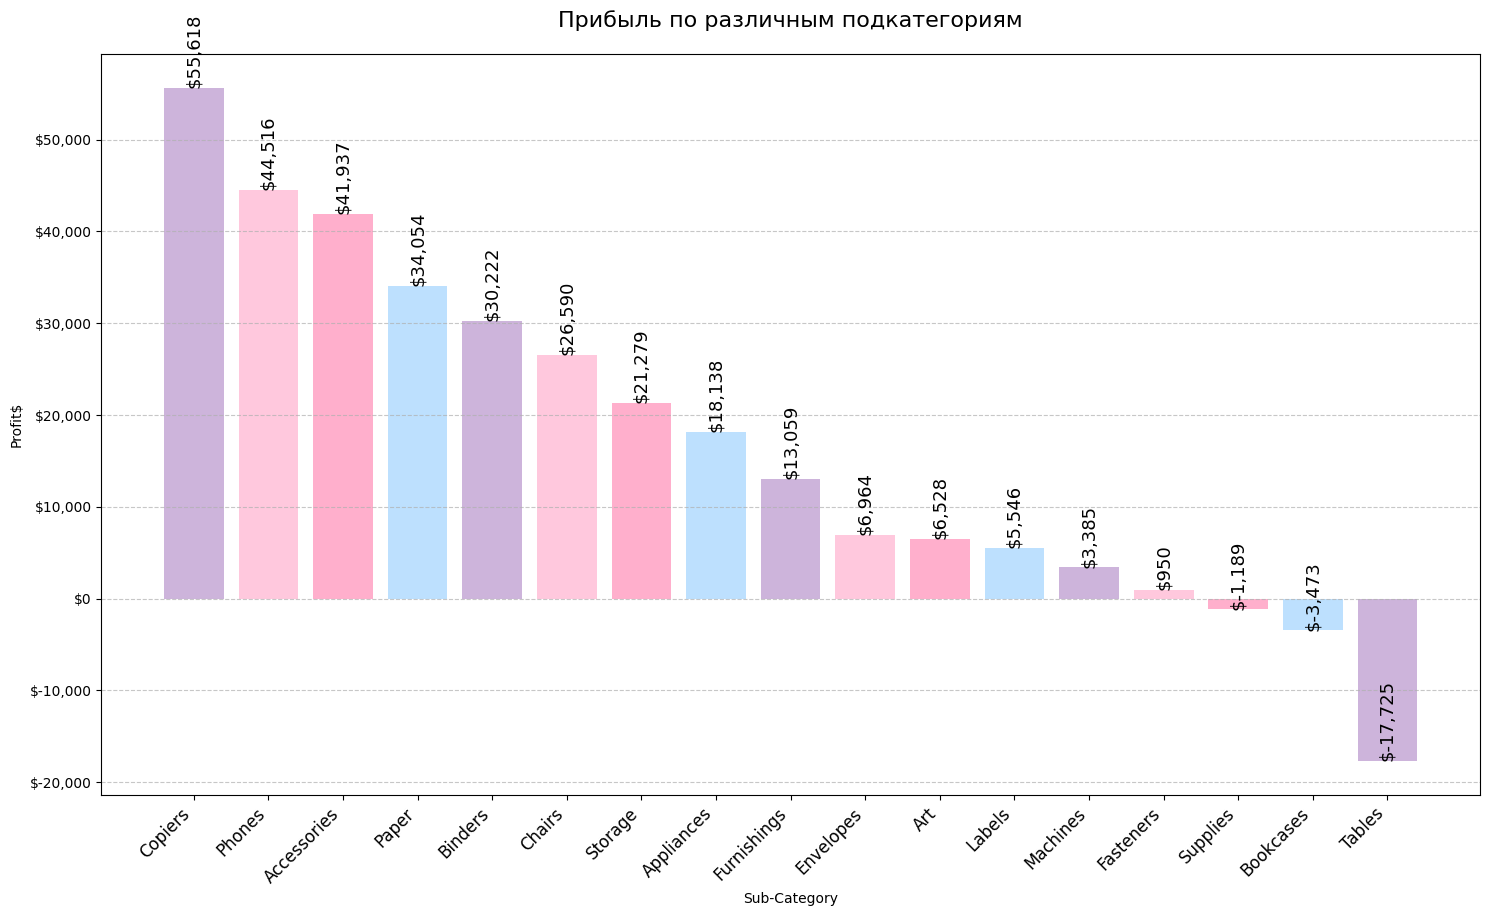

In [ ]:
df_bar_sub_category = df[['Sub-Category', 'Profit']]
df_bar_sub_category = df_bar_sub_category.groupby('Sub-Category').sum().sort_values(by = 'Profit', ascending=False)
plt.figure(figsize=(15,10))
bars = plt.bar(x=df_bar_sub_category.index, height='Profit', color=colors, width=0.8, data=df_bar_sub_category)
plt.title('Прибыль по различным подкатегориям', size=16, pad=20)
plt.xlabel('Sub-Category')
plt.ylabel('Profit$')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', ha='center', va='bottom', rotation=90, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Adjust bottom margin
plt.subplots_adjust(bottom=0.2)
plt.show()

##### Анализ прибыльности подкатегорий:

- Некоторые подкатегории демонстрируют отрицательную прибыль (например, Столы, Книжные шкафы), что указывает на потенциальные зоны для улучшения или пересмотра.

- Технологические товары (например, Копировальные аппараты, Телефоны) входят в число наиболее прибыльных, что согласуется с высокой рентабельностью технологической категории, отмеченной в предыдущих анализах.

- Значительный разброс рентабельности между подкатегориями подчеркивает важность ассортиментной политики для общего результата бизнеса.

- Такой детализированный анализ прибыльности может помочь в управлении складскими запасами, ценовой стратегии и маркетинговой фокусировке на конкретных товарных линейках.

### Продажи и прибыль за весь период времени

In [ ]:
df_order = df[['Order Date','Sales', 'Profit']].sort_values('Order Date')
df_order = df_order.groupby('Order Date').sum()
df_order.head()

,Sales,Profit
Order Date,,
2014-01-03,16.448,5.5512
2014-01-04,288.060,-65.9901
2014-01-05,19.536,4.8840
2014-01-06,4407.100,1358.0524
2014-01-07,87.158,-71.9621


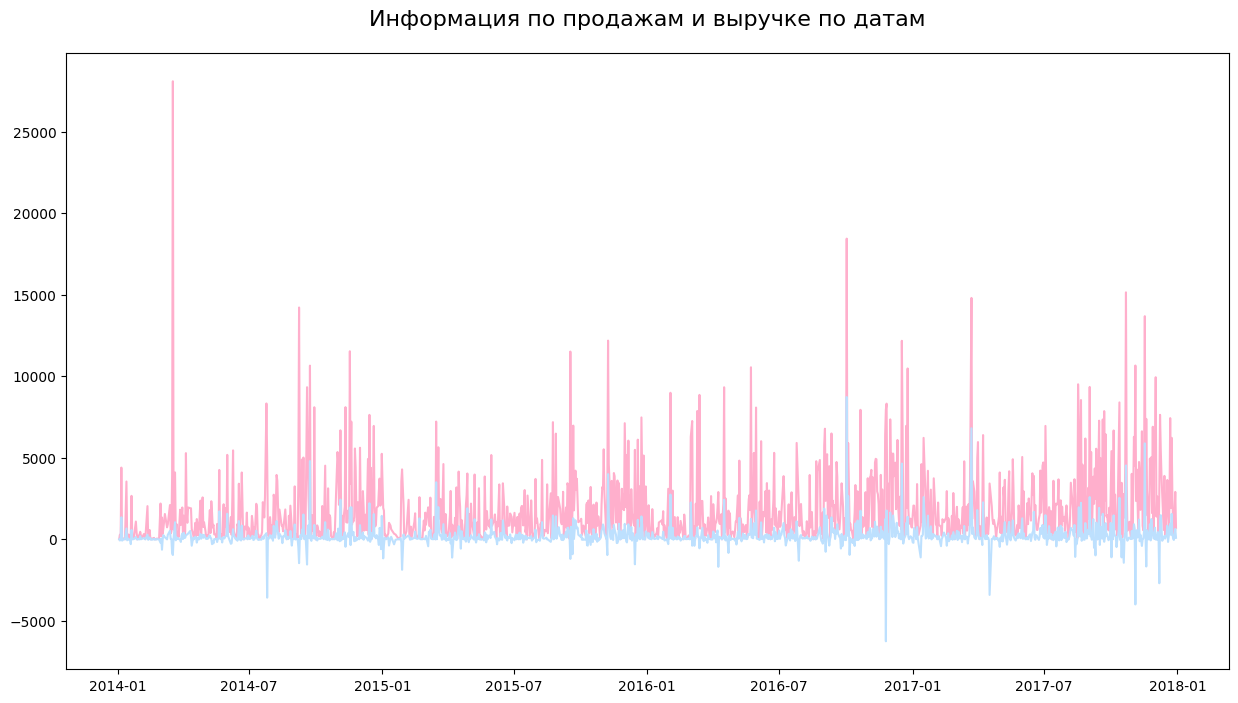

In [41]:
plt.figure(figsize=(15,8))
plt.plot(df_order.index, 'Sales', data=df_order, color=colors[2])
plt.plot(df_order.index, 'Profit', data=df_order, color=colors[3])
plt.title('Информация по продажам и выручке по датам', size=16, pad=20)
plt.show()

In [43]:
df_years = df[['Order_year', 'Order_month', 'Sales', 'Profit']].sort_values(['Order_year', 'Order_month'])
df_years['Date'] = pd.to_datetime(df_years['Order_year'].astype(str)+'-'+df_years['Order_month'].astype(str)+'-01')
df_years = df_years.groupby('Date')[['Sales', 'Profit']].sum().reset_index()
df_years.head()

,Date,Sales,Profit
0,2014-01-01,14236.895,2450.1907
1,2014-02-01,4519.892,862.3084
2,2014-03-01,55691.009,498.7299
3,2014-04-01,28295.345,3488.8352
4,2014-05-01,23648.287,2738.7096


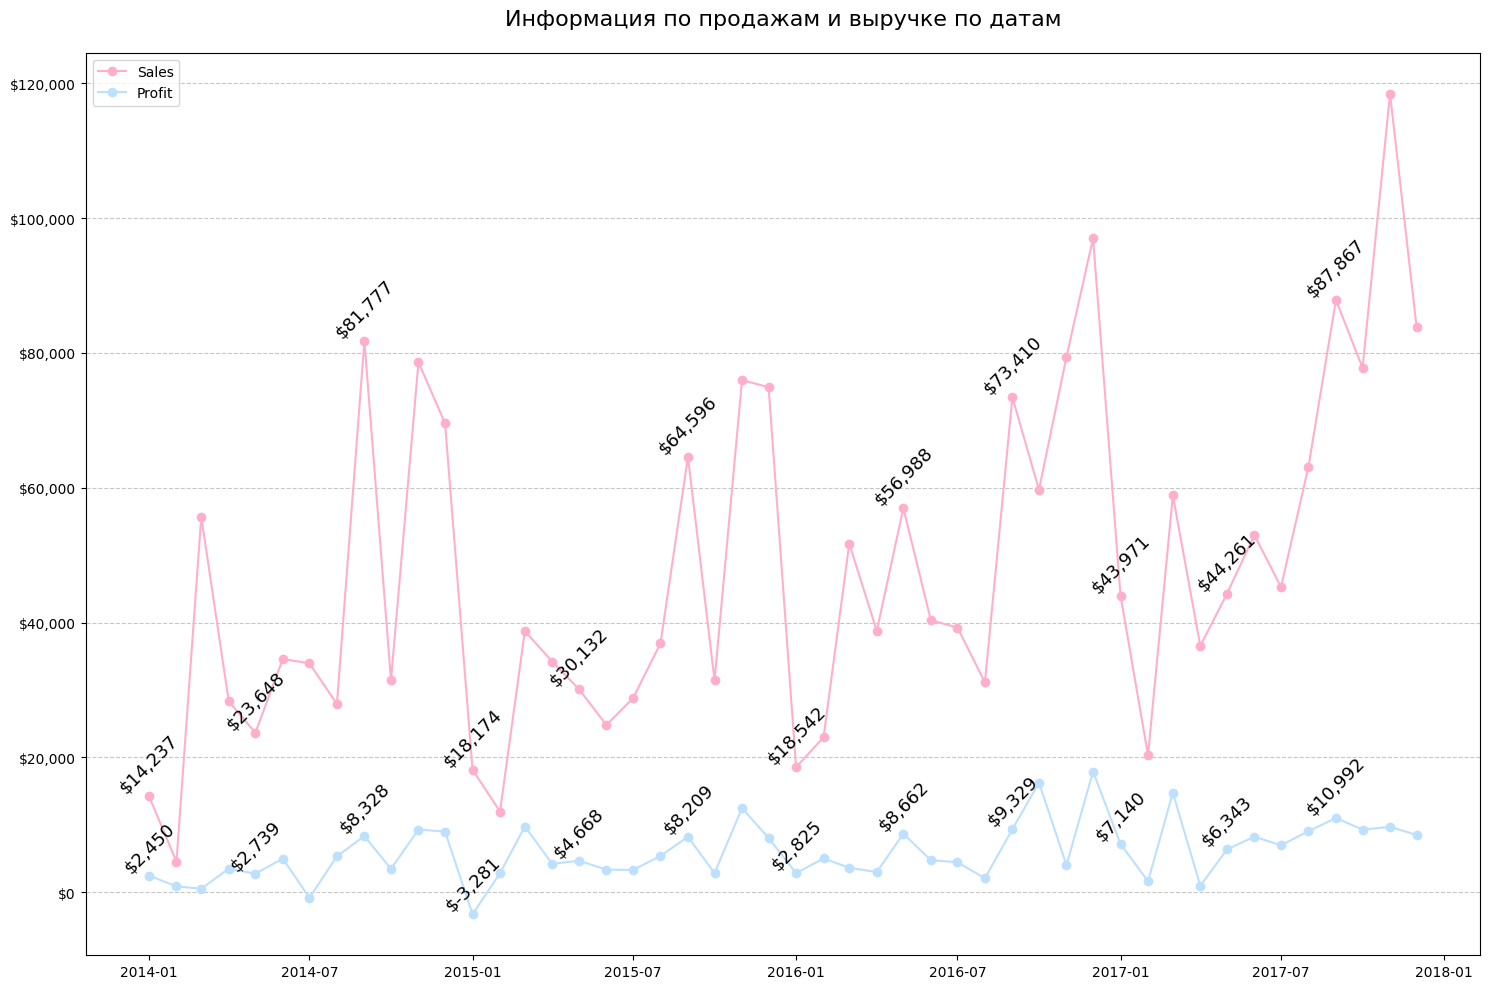

In [44]:
plt.figure(figsize=(15,10))
plt.plot(df_years.Date, 'Sales', data=df_years, color=colors[2], marker='o')
plt.plot(df_years.Date, 'Profit', data=df_years, color=colors[3], marker='o')
plt.title('Информация по продажам и выручке по датам', size=16, pad=20)
for column in ['Sales', 'Profit']:
    for i, (date, value) in enumerate(zip(df_years.Date, df_years[column])):
        if i%4==0:
            plt.text(date,value, f'${value:,.0f}', ha='center', va='bottom', rotation=45, fontsize=13)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.show()

##### Динамика продаж и прибыли:

- За данный период продажи и прибыль демонстрируют согласованные тенденции, при этом объем продаж, как и ожидалось, стабильно превышает показатели прибыли.

- Периодические всплески и спады свидетельствуют о колебаниях, которые могут быть связаны с сезонными факторами или рыночными событиями.

- Более детальный анализ показывает, что рост прибыли не всегда пропорционален росту продаж, что может указывать на изменяющуюся рентабельность в разные периоды.

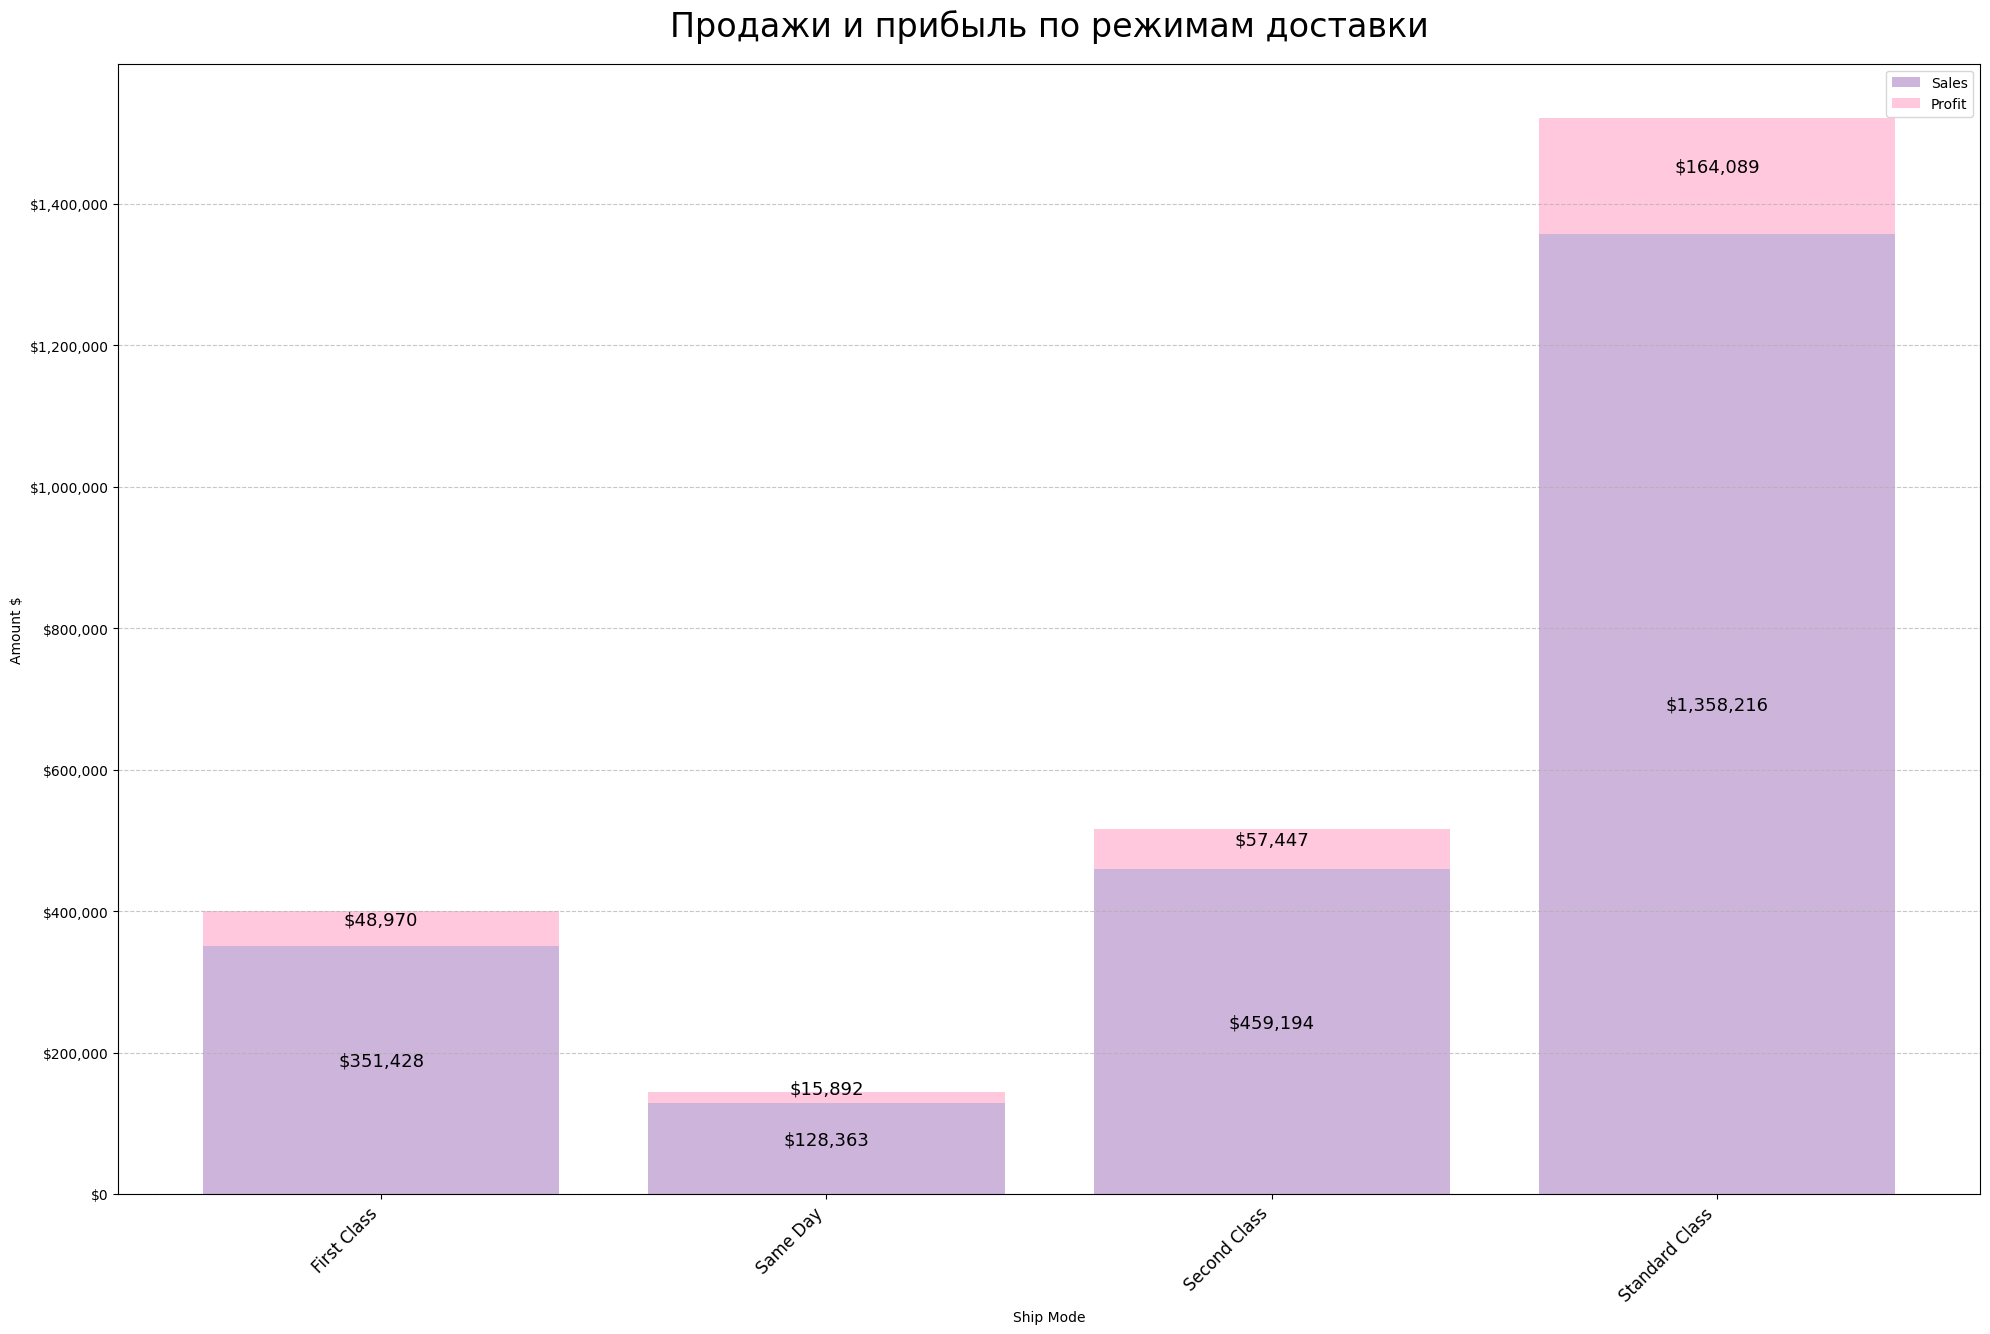

In [45]:
df_ship = df[['Ship Mode', 'Sales', 'Profit']]
df_ship = df_ship.groupby('Ship Mode').sum().reset_index()
plt.figure(figsize=(20,15))
plt.bar(x=df_ship['Ship Mode'], height=df_ship['Sales'], color=colors[0], width=0.8, data=df_ship)
plt.bar(x=df_ship['Ship Mode'], height=df_ship['Profit'], bottom=df_ship['Sales'], color=colors[1], width=0.8, data=df_ship)
plt.title('Продажи и прибыль по режимам доставки', size=24, pad=20)

plt.xlabel('Ship Mode')
plt.ylabel('Amount $')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for i, (sales, profit) in enumerate(zip(df_ship.Sales, df_ship.Profit)):
    plt.text(i, sales/2, f'${sales:,.0f}', ha='center', va='bottom',  fontsize=13)
    plt.text(i, sales+profit/2, f'${profit:,.0f}', ha='center', va='bottom',  fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(['Sales', 'Profit'])

# Adjust bottom margin
plt.subplots_adjust(bottom=0.2)
plt.show()

##### Соотношение продаж и прибыли:
- Хотя стандартная доставка лидирует по объему продаж, ее прибыльность не пропорциональна объемам.

- Экспресс-доставка и доставка за 2 дня демонстрируют лучшую рентабельность относительно объемов продаж.

---

##### Бизнес-инсайты:
- Популярность стандартной доставки говорит о приоритете клиентов в экономии средств над скоростью.

- Более высокая рентабельность быстрых способов доставки может указывать на премиальное ценообразование или эффективность этих услуг.

- Низкие показатели доставки в тот же день могут означать ее нишевый характер или недостаточную рентабельность.

---

##### Потенциальные стратегии:
- Исследовать пути повышения рентабельности стандартной доставки, учитывая ее высокие объемы продаж.

- Рассмотреть возможность активнее продвигать экспресс-доставку и доставку за 2 дня как более прибыльные варианты.

- Оценить целесообразность доставки в тот же день и необходимость ее улучшения или перепозиционирования.

### 10 клиентов с наибольшим количеством продаж

In [ ]:
best_clients_sales = df[['Customer Name', 'Sales', 'Profit']]
best_clients_sales = best_clients_sales.groupby('Customer Name').sum()
best_clients_sales['Total'] = best_clients_sales['Sales'] + best_clients_sales['Profit']
best_clients_sales = best_clients_sales.nlargest(10, 'Total')
best_clients_sales = best_clients_sales.reset_index()


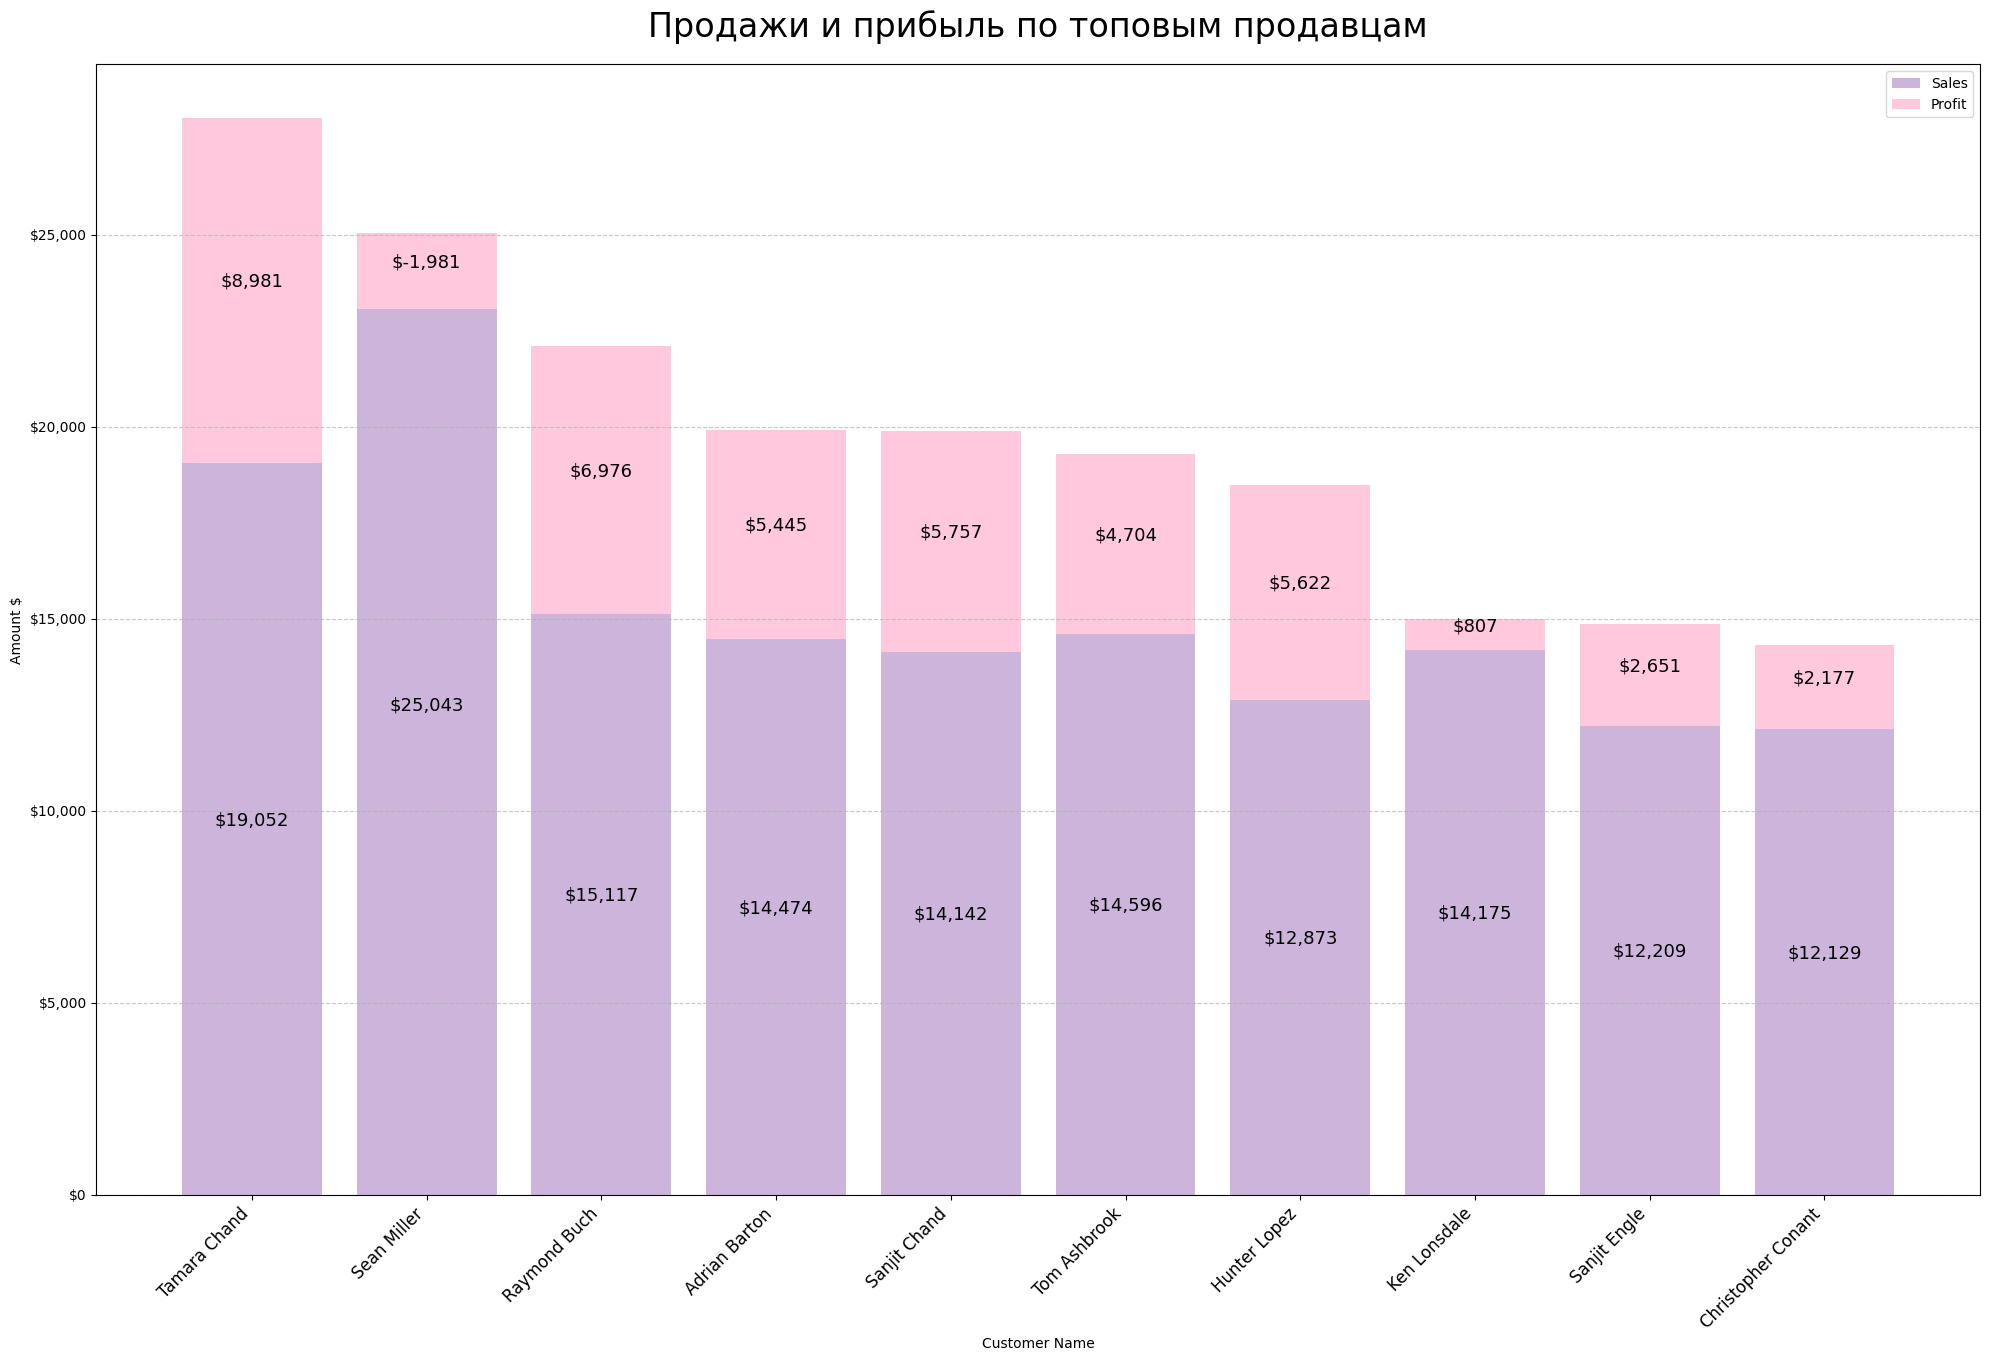

In [ ]:
plt.figure(figsize=(15,10))
plt.bar(x=best_clients_sales['Customer Name'], height=best_clients_sales['Sales'], color=colors[0], width=0.8, data=df_ship)
plt.bar(x=best_clients_sales['Customer Name'], height=best_clients_sales['Profit'], bottom=best_clients_sales['Sales'], color=colors[1], width=0.8, data=df_ship)
plt.title('Продажи и прибыль по топовым продавцам', size=16, pad=20)

plt.xlabel('Customer Name')
plt.ylabel('Amount $')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
for i, (sales, profit) in enumerate(zip(best_clients_sales.Sales, best_clients_sales.Profit)):
    plt.text(i, sales/2, f'${sales:,.0f}', ha='center', va='bottom',  fontsize=13)
    plt.text(i, sales+profit/2, f'${profit:,.0f}', ha='center', va='bottom',  fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(['Sales', 'Profit'])

# Adjust bottom margin
plt.subplots_adjust(bottom=0.2)
plt.show()

##### Анализ эффективности клиентов:

- Sean Miller выделяется исключительно высокими продажами (25,043$) c не отрицательной прибылью (1,981$)

- Это указывает, что несмотря на значительный доход от этого клиента, связанные затраты слишком велики, приводя к убыткам.

- Убытки могут быть вызваны скидками, высокими расходами на доставку или другими операционными издержками.

- Необходимо провести детальный анализ и рассмотреть стратегии снижения затрат или корректировки ценовой политики для данного клиента.

### Соотношение продаж и прибыли В различных Клиентских сегментах

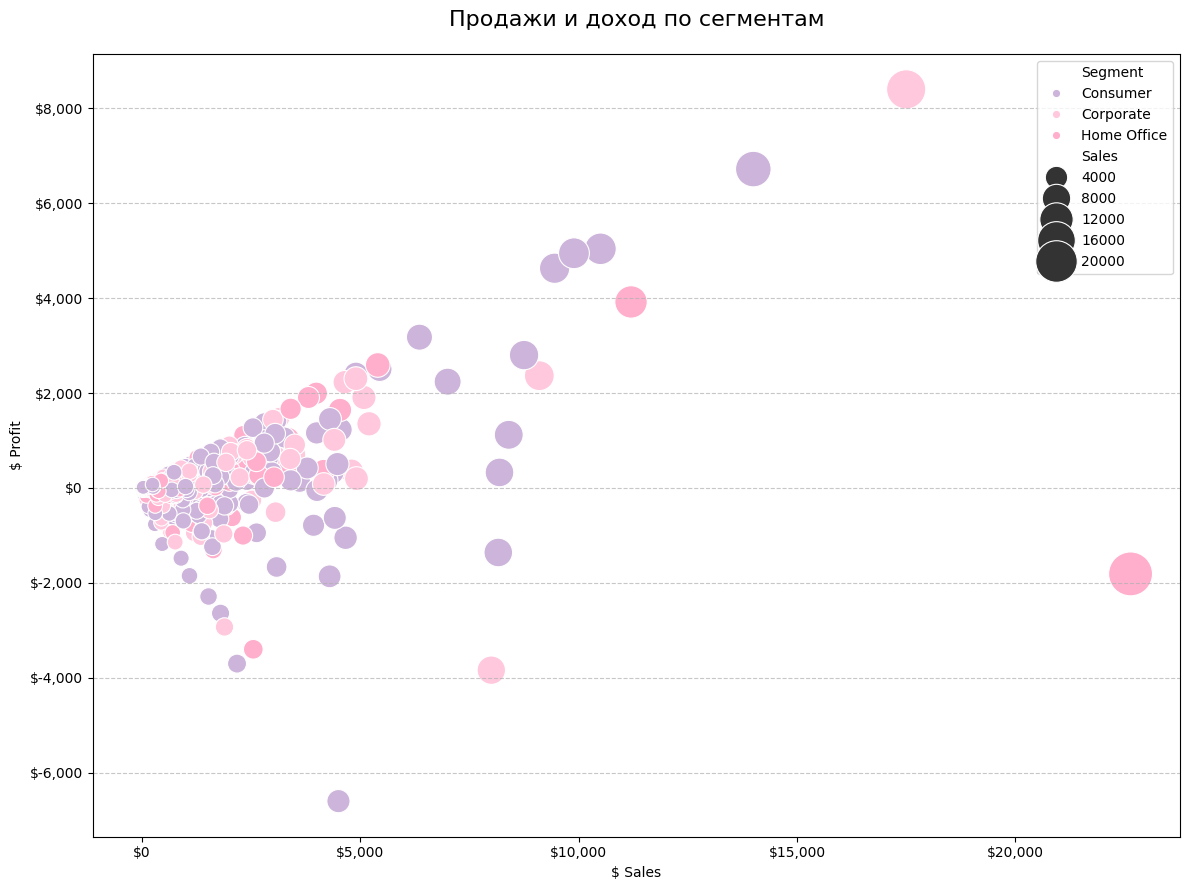

In [ ]:
df_segments  = df[['Segment','Profit','Sales']]
plt.figure(figsize=(12,9))
sns.scatterplot(x=df_segments.Sales, y=df_segments.Profit, size=df_segments.Sales, sizes=(100,1000), hue=df_segments.Segment, palette=colors)
plt.title('Продажи и доход по сегментам', size=16, pad=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('$ Sales')
plt.ylabel('$ Profit')
plt.tight_layout()
plt.show()


##### Анализ эффективности сегментов:

- Ни один сегмент не демонстрирует стабильного превосходства по показателям продаж или прибыли.

- Наличие отрицательных значений прибыли указывает на необходимость анализа ценовой политики и структуры затрат.

- Высокие объемы продаж не всегда соответствуют высокой прибыльности, что выявляет потенциал для улучшения маржинальности.

---

##### Потенциальные стратегии:

- Изучить причины возникновения отрицательной прибыли во всех сегментах.

- Проанализировать наиболее прибыльные случаи, чтобы определить успешные факторы и возможность их тиражирования.

- Разработать индивидуальные стратегии для сегментов, так как текущий подход не показывает четких различий в эффективности.

- Исследовать причины снижения прибыли при крупных продажах и рассмотреть корректировку цен или структуры затрат для высокодоходных сделок.

### Соотношение продаж и прибыли При различных режимах доставки

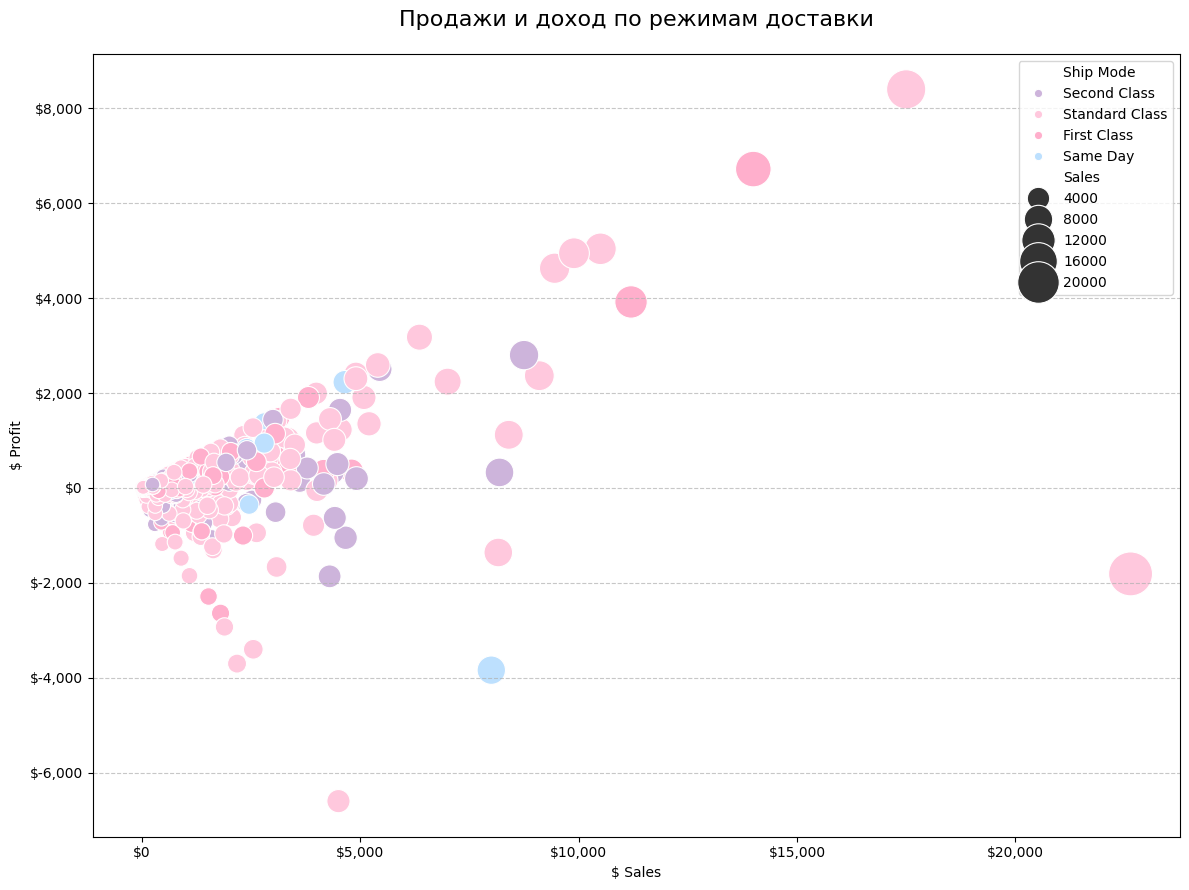

In [ ]:
df_segments  = df[['Ship Mode','Profit','Sales']]
plt.figure(figsize=(12,9))
sns.scatterplot(x=df_segments.Sales, y=df_segments.Profit, size=df_segments.Sales, sizes=(100,1000), hue=df_segments['Ship Mode'], palette=colors)
plt.title('Продажи и доход по режимам доставки', size=16, pad=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('$ Sales')
plt.ylabel('$ Profit')
plt.tight_layout()
plt.show()

##### Анализ эффективности способов доставки:

- Ни один способ доставки не демонстрирует стабильного преимущества по показателям продаж или прибыли.

- Наличие убыточных позиций указывает на необходимость пересмотра ценовой политики и структуры затрат для всех способов доставки.

- Высокие объемы продаж не всегда обеспечивают хорошую прибыль, что свидетельствует о возможностях улучшения маржинальности независимо от способа доставки.

---

##### Возможные стратегии:
- Исследовать причины отрицательной прибыли для всех способов доставки.

- Проанализировать наиболее прибыльные случаи, чтобы выявить успешные факторы и возможность их применения к разным способам доставки.

- Разработать индивидуальные стратегии для каждого способа доставки, так как текущие данные не показывают четкой разницы в эффективности.

- Изучить причины снижения прибыли при крупных заказах и рассмотреть корректировку цен или затрат для дорогих покупок с учетом способа доставки.

- Оценить, влияют ли определенные типы товаров или категории клиентов на выбор способа доставки и его рентабельность.

### Соотношение продаж и прибыли В разных категориях

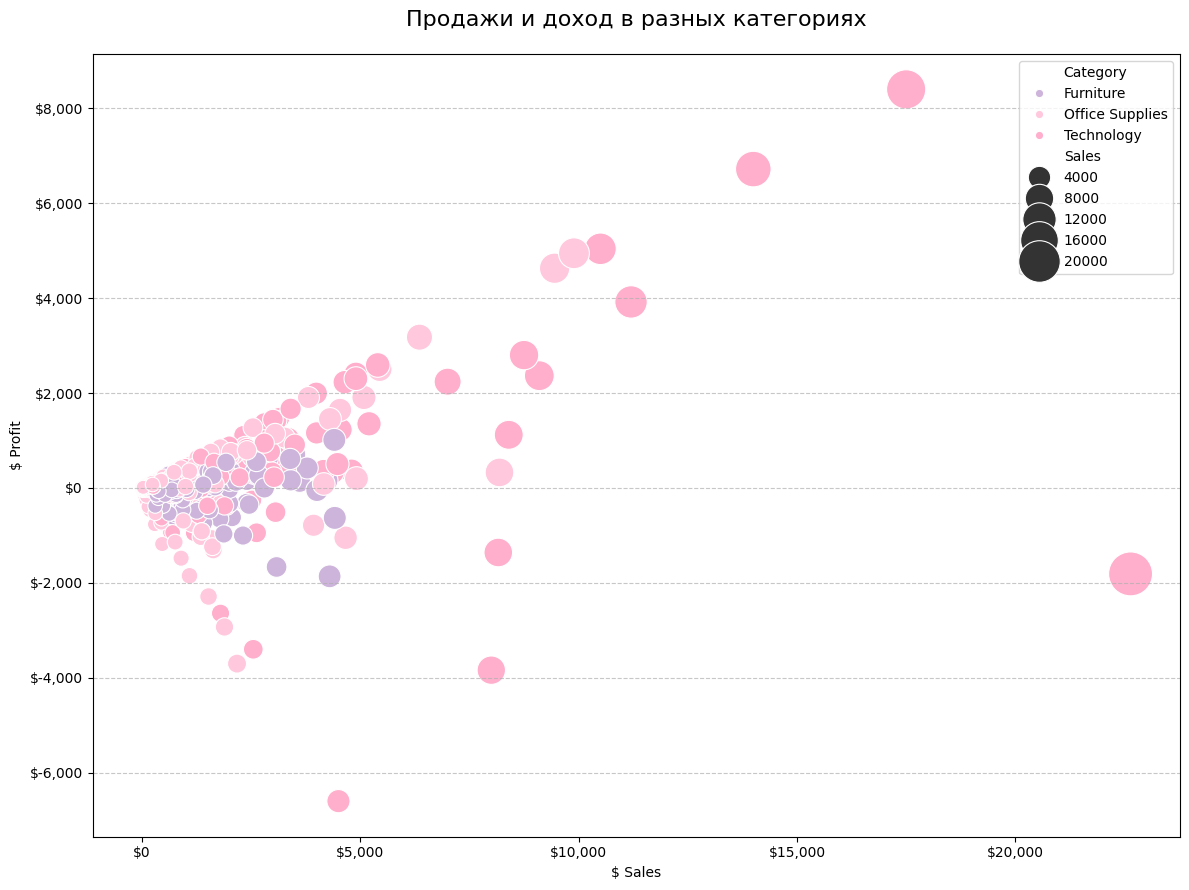

In [ ]:
df_segments  = df[['Category','Profit','Sales']]
plt.figure(figsize=(12,9))
sns.scatterplot(x=df_segments.Sales, y=df_segments.Profit, size=df_segments.Sales, sizes=(100,1000), hue=df_segments.Category, palette=colors)
plt.title('Продажи и доход в разных категориях', size=16, pad=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('$ Sales')
plt.ylabel('$ Profit')
plt.tight_layout()
plt.show()

##### Наблюдения: 

- На данном графике можно выделить категорию со средним количеством продаж и домтаточно низкой прибылью - "Furniture", возможно, эта категория представляет собой массовые товары с низкими ценами и высокой конкуренцией. 
 
- Категории "Office Supplies" и "Technology" демонстрируют более сбалансированное соотношение между объемом продаж и прибылью. Это может свидетельствовать о том, что товар имеет хороший потенциал для увеличения продаж без значительных потерь на прибыльности.

### Соотношение продаж и прибыли В разных подкатегориях

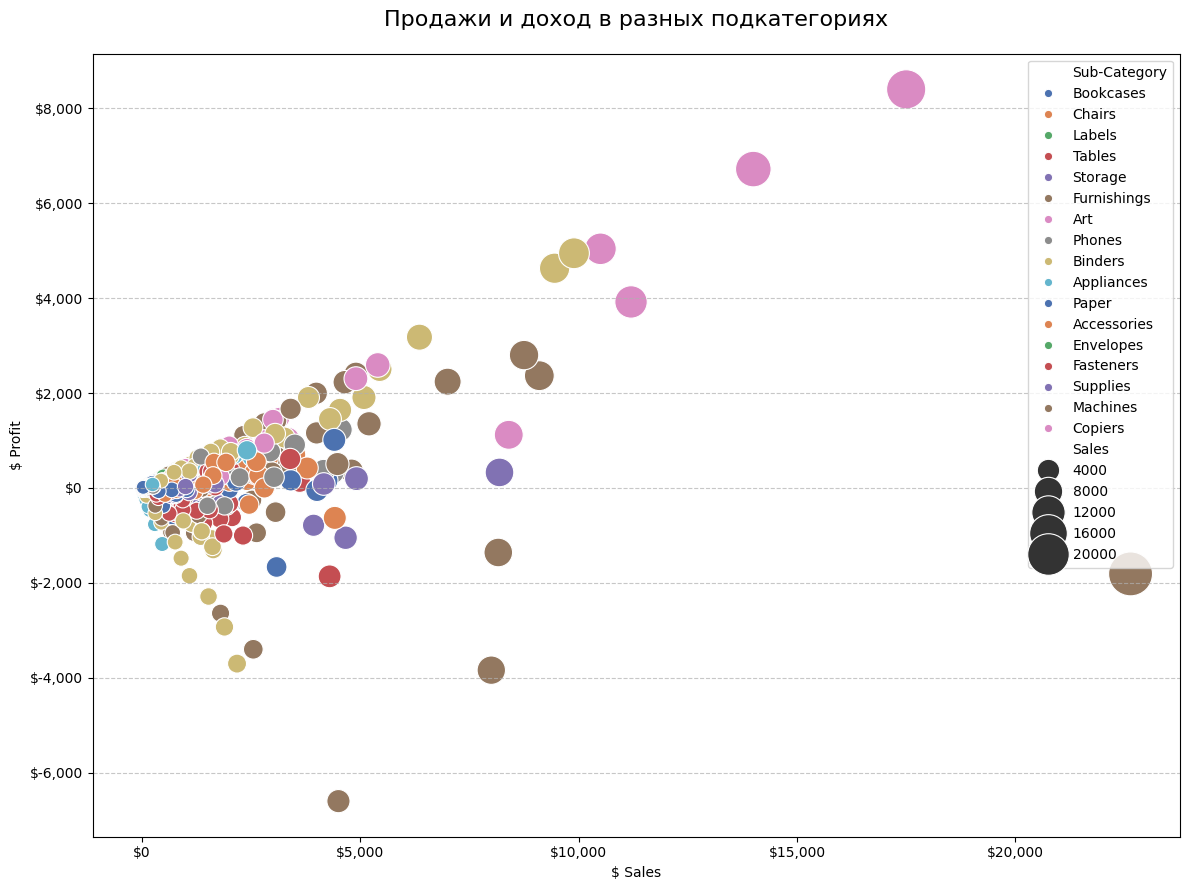

In [ ]:
df_segments  = df[['Sub-Category','Profit','Sales']]
plt.figure(figsize=(12,9))
sns.scatterplot(x=df_segments.Sales, y=df_segments.Profit, size=df_segments.Sales, sizes=(100,1000), hue=df_segments['Sub-Category'], palette='deep')
plt.title('Продажи и доход в разных подкатегориях', size=16, pad=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('$ Sales')
plt.ylabel('$ Profit')
plt.tight_layout()
plt.show()

##### Наблюдения:

- Различные подкатегории демонстрируют уникальные модели в отношении диапазона продаж и рентабельности.

- Некоторые подкатегории характеризуются высокой концентрацией низкодоходных, но прибыльных продаж.

- Другие подкатегории показывают более крупные продажи, но с нестабильной рентабельностью.

- Наличие убыточных позиций в нескольких подкатегориях указывает на необходимость дифференцированного ценообразования и оптимизации затрат.



### Основные наблюдения по проекту и рекомендации:

1. Изучить причины отрицательной прибыли для каждой подкатегории и разработать адресные решения.

2. Проанализировать наиболее прибыльные кейсы в каждой подкатегории для выявления успешных факторов и их возможного тиражирования.

3. Разработать индивидуальные ценовые и маркетинговые стратегии с учетом выявленных взаимосвязей между продажами и прибылью.

4. Для подкатегорий с крупными, но нестабильными продажами сосредоточиться на повышении стабильности маржи.

5. Для подкатегорий с преимущественно мелкими продажами изучить возможности увеличения среднего чека без ущерба для рентабельности.

6. Рассмотреть комплексные предложения и кросс-подкатегорийные акции для усиления сильных сторон каждой товарной группы.

7. Оценить эффективность подкатегорий в рамках их основных категорий для выявления закономерностей и аномалий.